In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import requests
import datetime
from datetime import datetime
import sqlite3
import numpy as np
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import geopandas as gpd
import geodatasets


C:\Users\damie\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# **How does air pollution affect life expectancy?**

## Hypothesis/analysis goal (Ask)

As industrialization accelerates globally, a critical public health question is how long-term exposure to poor air quality affects the overall life expectancy of a population. Testing this hypothesis could support government policymakers and international health organizations in prioritizing environmental regulations that directly improve citizen longevity and reduce systemic healthcare burdens.

<br>

In this context, we will look at global data from countries across all continents to explore how national air pollution levels affect life expectancy. Because life expectancy is also heavily influenced by a country's wealth, we will include GDP as a control variable to ensure our analysis is accurate. For this analysis, the datasets we using for pollution, life expectancy, death, and GDP will be measured as national annual averages rather than short-term or localized fluctuations.

<br>

Ultimately, our hypothesis is that higher levels of air pollution will be linked to a decrease in life expectancy.

## Data source identification and exploration (Prepare)

### Requirement Analysis


To approach this problem, we first need to collect data that represents people's life expectancy, specifically the average life expectancy at birth and death caused by air pollution for various countries over a chosen year. This data must be aligned with air quality measurements as well as economic data (GDP per capita) for the exact same locations and time periods.

<br>

To ensure an accurate and reliable analysis, our dataset requires global coverage, encompassing countries across all continents with varying levels of wealth and industrial activity. Because we are looking at macro-level national trends, individual citizen health records or daily, localized pollution readings are not required. Instead, one annual mean summary entry per country for each of our three variables will be completely sufficient to test our hypothesis.

###List of considered sources

In this section, we list out all the datasets we explored that might be useful for our investigation. Meanwhile, we have also identified 3 datasets that will be used for the analysis phase, based on the concepts we learned from SC3021 content. The datasets chosen will be noted "(chosen)" behind.

  * [Death Due to Air Pollution (DS1)](https://www.kaggle.com/datasets/akshat0giri/death-due-to-air-pollution-19902017) (chosen)

  * [ Asia's 2023 Air Report (2000+ Cities) (DS2)](https://www.kaggle.com/datasets/shruthiiiee/asia-2023-air-report-2000-cities)

  * [ AQI - Air Quality Index (DS3)](https://www.kaggle.com/datasets/azminetoushikwasi/aqi-air-quality-index-scheduled-daily-update)

  * [World Happiness Report for 2024 & World Happiness Report from 2005-2024 (DS4)](https://www.kaggle.com/datasets/jainaru/world-happiness-report-2024-yearly-updated) (chosen)

  * [PM2.5 Global Air Pollution 2010-2017 (DS5)](https://www.kaggle.com/datasets/kweinmeister/pm25-global-air-pollution-20102017) (chosen)
  
  * [World Population by Year (1950-2023) (DS6)](https://www.kaggle.com/datasets/chandanchoudhury/world-population-dataset?select=world_population_by_year_1950_2023.csv) (chosen)
  


### DS1: Death Due to Air Pollution Exploration



**Decscription**

This dataset has information on Indoor air pollution, Outdoor particulate matter and Outdoor ozone pollution deaths (per 100,000) from 231 different countries, from 1990 to 2017.



* Entity: It contains the name of the country.
* Code: It contain Code of the country.
* Year: Years range from 1990 to 2017
* Air pollution (total) (deaths per 100,000) : Contain total death.
* Indoor air pollution (deaths per 100,000) : Contains death due to indoor air pollution.
* Outdoor particulate matter (deaths per 100,000) : Contains death due to outdoor pollution.
* Outdoor ozone pollution (deaths per 100,000) : Death due to ozone pollution.
Inspiration

In [2]:
df1 = pd.read_csv("SC3021 Datasets/death-rates-from-air-pollution.csv")

df1.dtypes #datatype checking of each column


Entity                                              object
Code                                                object
Year                                                 int64
Air pollution (total) (deaths per 100,000)         float64
Indoor air pollution (deaths per 100,000)          float64
Outdoor particulate matter (deaths per 100,000)    float64
Outdoor ozone pollution (deaths per 100,000)       float64
dtype: object

In [3]:
display(df1.head())

print("Datatype of each column:")
print(df1.dtypes)

print("\nNumber of null values per column:")
display(df1.isnull().sum())

,Entity,Code,Year,"Air pollution (total) (deaths per 100,000)","Indoor air pollution (deaths per 100,000)","Outdoor particulate matter (deaths per 100,000)","Outdoor ozone pollution (deaths per 100,000)"
0,Afghanistan,AFG,1990,299.477309,250.362910,46.446589,5.616442
1,Afghanistan,AFG,1991,291.277967,242.575125,46.033841,5.603960
2,Afghanistan,AFG,1992,278.963056,232.043878,44.243766,5.611822
3,Afghanistan,AFG,1993,278.790815,231.648134,44.440148,5.655266
4,Afghanistan,AFG,1994,287.162923,238.837177,45.594328,5.718922


Datatype of each column:
Entity                                              object
Code                                                object
Year                                                 int64
Air pollution (total) (deaths per 100,000)         float64
Indoor air pollution (deaths per 100,000)          float64
Outdoor particulate matter (deaths per 100,000)    float64
Outdoor ozone pollution (deaths per 100,000)       float64
dtype: object

Number of null values per column:


Entity                                               0
Code                                               980
Year                                                 0
Air pollution (total) (deaths per 100,000)           0
Indoor air pollution (deaths per 100,000)            0
Outdoor particulate matter (deaths per 100,000)      0
Outdoor ozone pollution (deaths per 100,000)         0
dtype: int64

**Completeness of data:**

Every column except “Code” has no null values.

However, “Code” is just a 3-letter abbreviation of the country’s name “Entity”.

Thus, we would still be able to conduct thorough analysis of each country’s deaths due to air pollution.

**Exploration of Death due to air pollution:**



In [4]:
# Get the unique country entries
unique_country_ds1 = pd.concat([df1['Entity']]).unique()

# Print the list of unique countries
print(unique_country_ds1)

total_countries_covered_ds1 = unique_country_ds1.size
print()
print(f"Total countries covered: {total_countries_covered_ds1}")

['Afghanistan' 'Albania' 'Algeria' 'American Samoa' 'Andean Latin America'
 'Andorra' 'Angola' 'Antigua and Barbuda' 'Argentina' 'Armenia'
 'Australasia' 'Australia' 'Austria' 'Azerbaijan' 'Bahamas' 'Bahrain'
 'Bangladesh' 'Barbados' 'Belarus' 'Belgium' 'Belize' 'Benin' 'Bermuda'
 'Bhutan' 'Bolivia' 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'Brunei'
 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cambodia' 'Cameroon' 'Canada'
 'Cape Verde' 'Caribbean' 'Central African Republic' 'Central Asia'
 'Central Europe' 'Central Europe, Eastern Europe, and Central Asia'
 'Central Latin America' 'Central Sub-Saharan Africa' 'Chad' 'Chile'
 'China' 'Colombia' 'Comoros' 'Congo' 'Costa Rica' "Cote d'Ivoire"
 'Croatia' 'Cuba' 'Cyprus' 'Czech Republic' 'Democratic Republic of Congo'
 'Denmark' 'Djibouti' 'Dominica' 'Dominican Republic' 'East Asia'
 'Eastern Europe' 'Eastern Sub-Saharan Africa' 'Ecuador' 'Egypt'
 'El Salvador' 'England' 'Equatorial Guinea' 'Eritrea' 'Estonia'
 'Ethiopia' 'Fiji' 'Finland' 'Fra

Since the dataset has some null values under "Code", we checked the number of unique countries that we have using the "Entity" column. This resulted in 231 unique countries.

However, this dataset only includes information about deaths due to air pollution, but not how much air pollution each country has. Hence, we would need to align this with different datasets that include the levels of air pollution in each country in order to investigate relationships and correlations between these 2 findings.

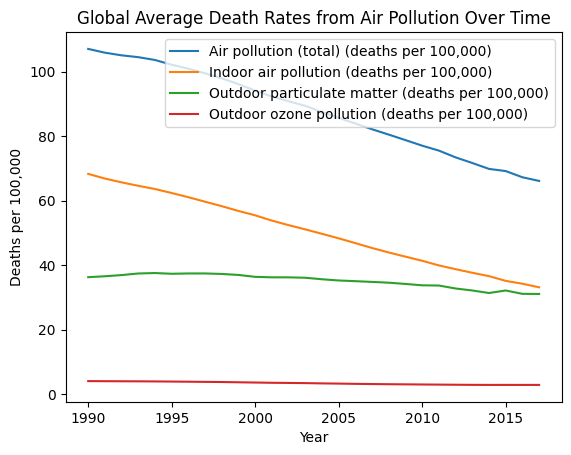

In [5]:
avg_by_year = df1.groupby("Year")[
    [
        "Air pollution (total) (deaths per 100,000)",
        "Indoor air pollution (deaths per 100,000)",
        "Outdoor particulate matter (deaths per 100,000)",
        "Outdoor ozone pollution (deaths per 100,000)",
    ]
].mean()

plt.figure()

for col in avg_by_year.columns:
    plt.plot(avg_by_year.index, avg_by_year[col], label=col)

plt.xlabel("Year")
plt.ylabel("Deaths per 100,000")
plt.title("Global Average Death Rates from Air Pollution Over Time")
plt.legend()
plt.show()


This graph is not population weighted. Each country/region contributes equally
(the average was found based on each country's air pollution deaths per 100,000)

**Data Quality Considerations**

The following shows some advantages of using this dataset for our analysis:

* The dataset was sourced from Kaggle, ensuring a high level of data reliability

* It aligns perfectly with our research objectives, providing the necessary granularity to answer our core questions

* The schema is straightforward, with clearly defined columns that minimize the risk of interpretational errors

* The dataset offers extensive geographical coverage and a negligible number of null values, ensuring more robust analysis

However, we acknowledge that this dataset lacks the total number of deaths for each country, which could result in A country with a high rate but small population looking worse than a country with a lower rate but millions more deaths. perhaps **we require another dataset with total population for each country**, and calculate the total number of deaths due to air pollution with the formula (total population/100,000)*(number of deaths per 100,000)


**Conclusion for DS1**

Overall, we have decided to include this dataset in our analysis because:

It aligns closely with our research objectives

Complementary datasets to validate or enhance this data are readily available

### DS2: Asia's 2023 Air Report Exploration



**Description**

This dataset contains the average air pollution index across 2164 Asian cities in 2023, with readings from each month.

In [6]:
df2 = pd.read_csv("SC3021 Datasets/AirQuality Dataset.csv")

display(df2.head())

print("\nNumber of null values per column:")
display(df2.isnull().sum())


,Rank,City,Country,2023,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
0,1,Begusarai,India,118.9,31.2,235.3,156.8,113,109.3,99,63.8,61.8,71.5,61.8,210.5,285
1,2,Guwahati,India,105.4,220.2,168.1,129.2,112.2,69.5,51.3,46.6,60.2,76.7,76.4,126.9,128
2,3,Delhi,India,102.1,171.8,114.3,77.4,71,67.4,42.9,35.3,34.8,39.7,106.3,255.1,210
3,4,Mullanpur,India,100.4,106.3,123.7,78.1,56.6,53.4,53.9,63.2,59.7,59.6,110.4,253,201.4
4,5,Lahore,Pakistan,99.5,143.2,117.3,73.8,52.9,52.4,46.4,39.8,42.2,53.8,125.9,251,197.5



Number of null values per column:


Rank       0
City       0
Country    0
2023       0
Jan        0
Feb        0
Mar        0
Apr        0
May        0
Jun        0
Jul        0
Aug        0
Sep        0
Oct        0
Nov        0
Dec        0
dtype: int64

**Explanation**

We first imported the dataset and saved it as a dataframe. We decided that grouping and sorting the data by country would make it easier to gauge the reliability of this dataset and think of effective ways to utilise the data. To achieve this, we grouped the data using the 'Country' column and sorted the list in descending order based on the number of cities.

In [7]:
grouped_by_country = df2.groupby('Country')['City'].nunique().reset_index()
grouped_by_country.columns = ['Country', 'Count']
grouped_by_country_sorted = grouped_by_country.sort_values(by='Count', ascending=False)

print("List of countries by number of cities:")
display(grouped_by_country_sorted)

List of countries by number of cities:


,Country,Count
13,Japan,636
5,China,482
9,India,256
34,Thailand,196
35,Turkey,102
30,South Korea,78
12,Israel,63
19,Malaysia,63
10,Indonesia,46
32,Taiwan,35


From this list of countries, we can notice the big difference in the number of cities from each country included in the data set. This may lead to unreliable analysis for countries with less readings as the data is easily skewed by outliers.

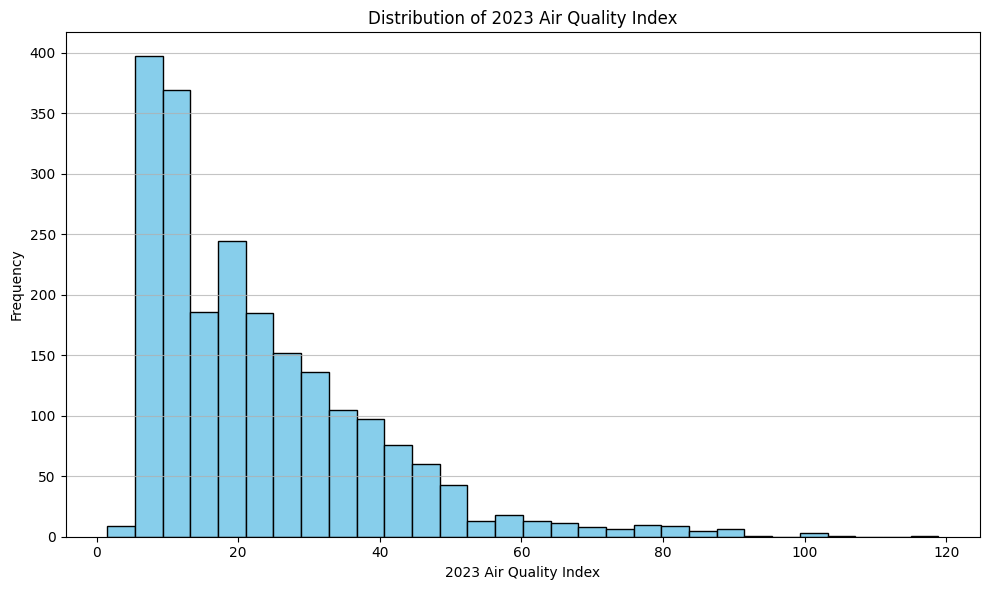

In [8]:
plt.figure(figsize=(10, 6))
plt.hist(df2['2023'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('2023 Air Quality Index')
plt.ylabel('Frequency')
plt.title('Distribution of 2023 Air Quality Index')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

To investigate the range of air quality index this dataset provides, we plotted a histogram to visualise the distribution of AQI range. From the graph, we notice that a majority of the readings are within the moderate/healthy range, which may lead to ineffective analysis due to very similar readings across all most of the countries.

**Data Quality Considerations**

The following shows some advantages of using this dataset for our analysis:

* This dataset is retrieved from Kaggle which is a reliable source of dataset
* This dataset is straight forward and easy to understand



**Conclusion for DS2**

After the data exploration, we have decided not to include this dataset in our analysis. Despite having large numbers of data and cities, we felt that the distribution of the readings were too inconsistent. Japan had over 600 readings, whereas a few of the countries only had 1. Another constraint is that this dataset only contains data on Asian countries. Further highlighting the limited sample size which may lead to unreliable results.

### DS3: AQI - Air Quality Index Exploration


**Description**

This Kaggle dataset covers the Air Quality Index (AQI) of most of the countries in the world. The AQI is used to record daily air quality. It tells us the exact condition of the air quality. The AQI focuses on health effects we may experience within a few hours or days after breathing polluted air.

The following provides the description on each column value:
* **Date:** Date when the data is recorded
* **Country:** The country where the data is recorded
* **Status:** Brief summary of the air condition
* **AQI Value:** Value of AQI

It is also important to note that **multiple AQI Value** can be present for same day since AQI value may differ from morning to night. Hence, it is essential for us to take the average by date for each country to ensure accuracy.


In [9]:
#import dataset 3 (AQI)
df3 = pd.read_csv("SC3021 Datasets/AQI.csv")

#verify output
display(df3.head())

# Check for null values
print("\nNumber of null values per column:")
display(df3.isnull().sum())

,Date,Country,Status,AQI Value
0,2022-07-21,Albania,Good,14
1,2022-07-21,Algeria,Moderate,65
2,2022-07-21,Andorra,Moderate,55
3,2022-07-21,Angola,Unhealthy for Sensitive Groups,113
4,2022-07-21,Argentina,Moderate,63



Number of null values per column:


Date         0
Country      0
Status       0
AQI Value    0
dtype: int64

**Exploration on AQI values**

To start off, we imported the dataset into google collab and saved it as a dataframe.

Observing the entries, we can see that the date are in yyyy-mm-dd format, which we might need to take note when merging with other datasets.

To verify the claim that this dataset indeed covers **most of the countries in the world**, we will need to do a unique value check in the following cell:


In [10]:
# Get the unique country entries
unique_country_ds3 = pd.concat([df3['Country']]).unique()

# Print the list of unique countries
print(unique_country_ds3)

total_countries_covered_ds3 = unique_country_ds3.size
print()
print(f"Total countries covered: {total_countries_covered_ds3}")

['Albania' 'Algeria' 'Andorra' 'Angola' 'Argentina' 'Armenia' 'Australia'
 'Austria' 'Azerbaijan' 'Bahrain' 'Bangladesh' 'Belarus' 'Belgium'
 'Belize' 'Bermuda' 'Bolivia' 'Bosnia and Herzegovina' 'Brazil' 'Brunei'
 'Bulgaria' 'Burkina Faso' 'Cambodia' 'Canada' 'Cape Verde'
 'Cayman Islands' 'Central African Republic' 'Chad' 'Chile' 'China'
 'Colombia' 'Costa Rica' 'Croatia' 'Cyprus' 'Czech Republic' 'Denmark'
 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador' 'Estonia' 'Ethiopia'
 'Finland' 'France' 'French Guiana' 'Gabon' 'Gambia' 'Georgia' 'Germany'
 'Ghana' 'Gibraltar' 'Greece' 'Grenada' 'Guadeloupe' 'Guam' 'Guatemala'
 'Honduras' 'Hong Kong' 'Hungary' 'Iceland' 'India' 'Indonesia' 'Iran'
 'Iraq' 'Ireland' 'Israel' 'Italy' 'Ivory Coast' 'Japan' 'Jersey' 'Jordan'
 'Kazakhstan' 'Kenya' 'Kosovo' 'Kuwait' 'Kyrgyzstan' 'Laos' 'Latvia'
 'Lebanon' 'Liberia' 'Liechtenstein' 'Lithuania' 'Luxembourg' 'Macao'
 'Macedonia' 'Madagascar' 'Malaysia' 'Malta' 'Martinique' 'Mexico'
 'Moldova' 'Mon

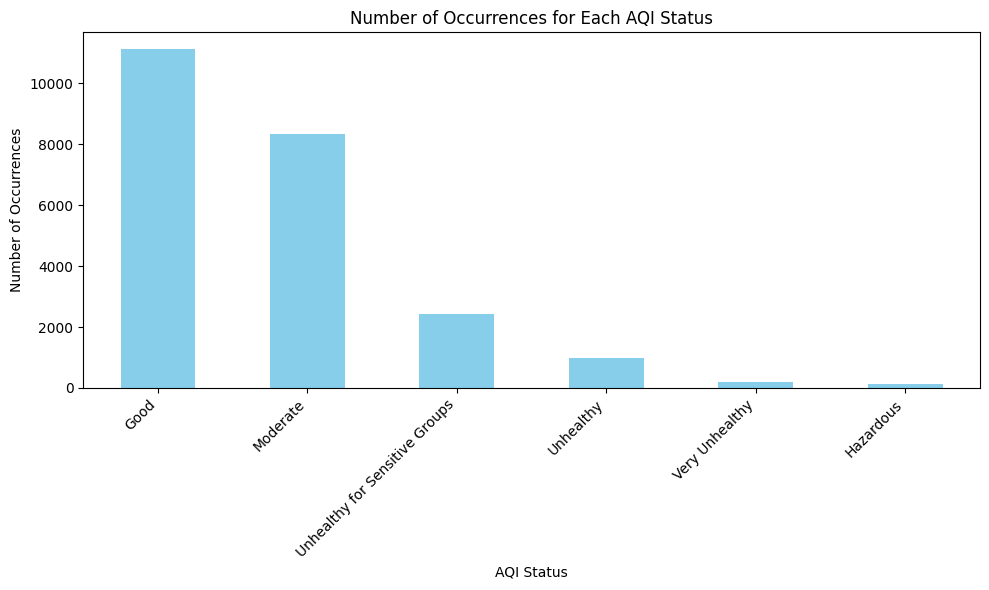

In [11]:
status_counts = df3['Status'].value_counts()

plt.figure(figsize=(10, 6))
status_counts.plot(kind='bar', color='skyblue')
plt.title('Number of Occurrences for Each AQI Status')
plt.xlabel('AQI Status')
plt.ylabel('Number of Occurrences')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

From the above, we can conclude that the geographical coverage of this dataset is adequate for our analysis since it covers countries from all main continents. Meanwhile, there are 6 different values for Status of AQI, which gives us a good range of air condition to analyse. However, it is important to note that the number of occurrences for each AQI status differs, which may post problems later on when we try to compare countries with different status.

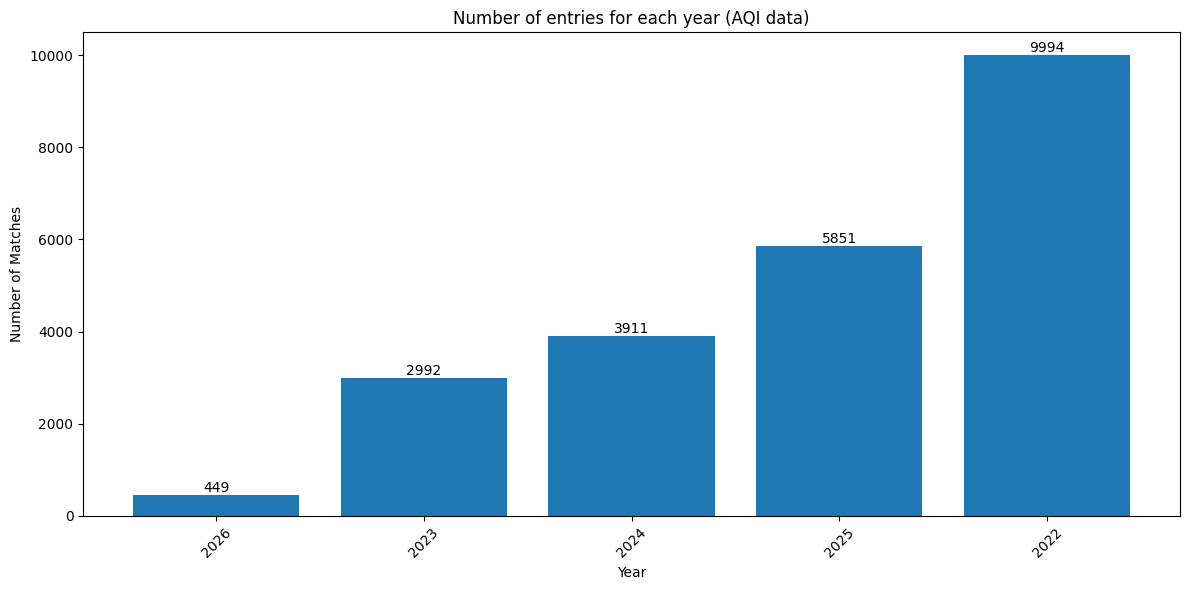

In [12]:
# Ensure 'Date' column is datetime type
df3['Date'] = pd.to_datetime(df3['Date'])
# Extract year from 'Date' and count occurrences
year_counts = df3.groupby(df3['Date'].dt.year)['Date'].count().sort_values(ascending=True)

#plot graph
plt.figure(figsize=(12, 6))
bars = plt.bar(year_counts.index.astype(str), year_counts.values)
plt.xlabel('Year')
plt.ylabel('Number of Matches')
plt.title('Number of entries for each year (AQI data)')
plt.xticks(rotation=45)
plt.tight_layout()

# Add value labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, round(yval, 2), ha='center', va='bottom')

plt.show()

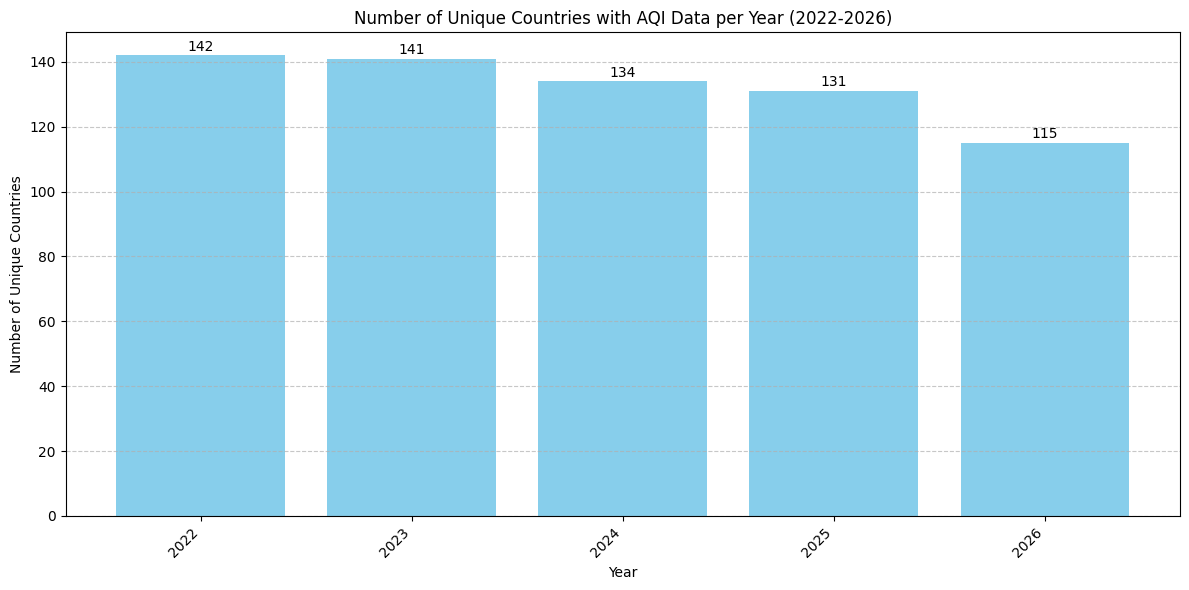

In [13]:
# Ensure 'Date' column is datetime type for df3
df3['Date'] = pd.to_datetime(df3['Date'])

# Extract year and count unique countries per year
unique_countries_per_year = df3.groupby(df3['Date'].dt.year)['Country'].nunique()

# Filter for years 2022 to 2026
unique_countries_per_year_filtered = unique_countries_per_year[(unique_countries_per_year.index >= 2022) & (unique_countries_per_year.index <= 2026)]

# Plotting the number of unique countries per year
plt.figure(figsize=(12, 6))
bars = plt.bar(unique_countries_per_year_filtered.index.astype(str), unique_countries_per_year_filtered.values, color='skyblue')
plt.xlabel('Year')
plt.ylabel('Number of Unique Countries')
plt.title('Number of Unique Countries with AQI Data per Year (2022-2026)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Add value labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, round(yval, 2), ha='center', va='bottom')

plt.show()

To further investigate the coverage of the datasets, we tried looking at the year of the entries. We realized the number of entries available ranges from 2022 to 2026, with 2022 having the most number of entries and 2026 having the least.

Meanwhile, we also investigated the number of unique countries entries for each year. The result is showing that the geographical coverage of the dataset did not drop much due to the lack of entries for later years.

**Data Quality Considerations**

Advantages of using this dataset:

* The dataset is easy to understand because it has a limited number of attributes and provides clear definitions for each.

* The dataset was retrieved from Kaggle, which is a reputable source for data.

Downsides of using this dataset:

* Extra work is required to convert the daily AQI entries into yearly averages.

* Data is only available from 2022 to 2026, which does not overlap with our primary air pollution dataset (DS1).

**Conclusions for DS3**

After the data exploration, we decided not to include this dataset in our subsequent analysis because:

* AQI values are only available from 2022 to 2026. This does not match the timeline in Dataset 1, which only provides data on deaths caused by air pollution until 2017.


### DS4: World Happiness Report Exploration


**Description**

This Kaggle dataset covers the Happiness Report of the countries around the world. It provides 9 indicators that may reflect the happiness level of the people in the countries. However, we are aware that not all the columns are relevant to our analysis since it is impossible for air quality to affect every single indicator below. Hence, we will only be looking at those indicators that we suspect are relevant to our topic.

The following provides the description on relevant column value:
* **Country name:** Name of the country
* **year:** The year when the data is recorded
* **Log GDP per capita:** The natural logarithm of the country's GDP per capita, adjusted for purchasing power parity (PPP) to account for differences in the cost of living between countries.
* **Healthy life expectancy at birth:** The average number of years a newborn infant would live in good health, based on mortality rates and life expectancy at different ages.



In [14]:
#import dataset 4 (Happiness Report)
df4 = pd.read_csv("SC3021 Datasets/World-happiness-report-updated_2024.csv", encoding='latin1')

#verify output
display(df4.head())


,Country name,year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect
0,Afghanistan,2008,3.724,7.350,0.451,50.5,0.718,0.164,0.882,0.414,0.258
1,Afghanistan,2009,4.402,7.509,0.552,50.8,0.679,0.187,0.850,0.481,0.237
2,Afghanistan,2010,4.758,7.614,0.539,51.1,0.600,0.118,0.707,0.517,0.275
3,Afghanistan,2011,3.832,7.581,0.521,51.4,0.496,0.160,0.731,0.480,0.267
4,Afghanistan,2012,3.783,7.661,0.521,51.7,0.531,0.234,0.776,0.614,0.268


In [15]:
# Check for null values
print("\nNumber of null values per column:")
display(df4.isnull().sum())

print("\nPercentage of null values per column:")
display(df4.isnull().sum() * 100 / len(df4))


Number of null values per column:


Country name                          0
year                                  0
Life Ladder                           0
Log GDP per capita                   28
Social support                       13
Healthy life expectancy at birth     63
Freedom to make life choices         36
Generosity                           81
Perceptions of corruption           125
Positive affect                      24
Negative affect                      16
dtype: int64


Percentage of null values per column:


Country name                        0.000000
year                                0.000000
Life Ladder                         0.000000
Log GDP per capita                  1.184934
Social support                      0.550148
Healthy life expectancy at birth    2.666102
Freedom to make life choices        1.523487
Generosity                          3.427846
Perceptions of corruption           5.289886
Positive affect                     1.015658
Negative affect                     0.677105
dtype: float64

In [16]:
#filter out irrelevant column
selected_columns = [
    'Country name',
    'year',
    'Log GDP per capita',
    'Healthy life expectancy at birth',
]

df4_filtered = df4[selected_columns].copy()
print(df4_filtered)

     Country name  year  Log GDP per capita  Healthy life expectancy at birth
0     Afghanistan  2008               7.350                            50.500
1     Afghanistan  2009               7.509                            50.800
2     Afghanistan  2010               7.614                            51.100
3     Afghanistan  2011               7.581                            51.400
4     Afghanistan  2012               7.661                            51.700
...           ...   ...                 ...                               ...
2358     Zimbabwe  2019               7.698                            53.100
2359     Zimbabwe  2020               7.596                            53.575
2360     Zimbabwe  2021               7.657                            54.050
2361     Zimbabwe  2022               7.670                            54.525
2362     Zimbabwe  2023               7.679                            55.000

[2363 rows x 4 columns]


After the import of dataset, we realized the number of NULL value is acceptable, which shows that this dataset is relatively complete.

**Exploration on Life Expectancy Indicators**

In [17]:
# Get the unique country entries
unique_country_ds4 = pd.concat([df4['Country name']]).unique()

# Print the list of unique countries
print(unique_country_ds4)

total_countries_covered_ds4 = unique_country_ds4.size
print()
print(f"Total countries covered: {total_countries_covered_ds4}")

['Afghanistan' 'Albania' 'Algeria' 'Angola' 'Argentina' 'Armenia'
 'Australia' 'Austria' 'Azerbaijan' 'Bahrain' 'Bangladesh' 'Belarus'
 'Belgium' 'Belize' 'Benin' 'Bhutan' 'Bolivia' 'Bosnia and Herzegovina'
 'Botswana' 'Brazil' 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cambodia'
 'Cameroon' 'Canada' 'Central African Republic' 'Chad' 'Chile' 'China'
 'Colombia' 'Comoros' 'Congo (Brazzaville)' 'Congo (Kinshasa)'
 'Costa Rica' 'Croatia' 'Cuba' 'Cyprus' 'Czechia' 'Denmark' 'Djibouti'
 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador' 'Estonia' 'Eswatini'
 'Ethiopia' 'Finland' 'France' 'Gabon' 'Gambia' 'Georgia' 'Germany'
 'Ghana' 'Greece' 'Guatemala' 'Guinea' 'Guyana' 'Haiti' 'Honduras'
 'Hong Kong S.A.R. of China' 'Hungary' 'Iceland' 'India' 'Indonesia'
 'Iran' 'Iraq' 'Ireland' 'Israel' 'Italy' 'Ivory Coast' 'Jamaica' 'Japan'
 'Jordan' 'Kazakhstan' 'Kenya' 'Kosovo' 'Kuwait' 'Kyrgyzstan' 'Laos'
 'Latvia' 'Lebanon' 'Lesotho' 'Liberia' 'Libya' 'Lithuania' 'Luxembourg'
 'Madagascar' 'Malawi' 'M

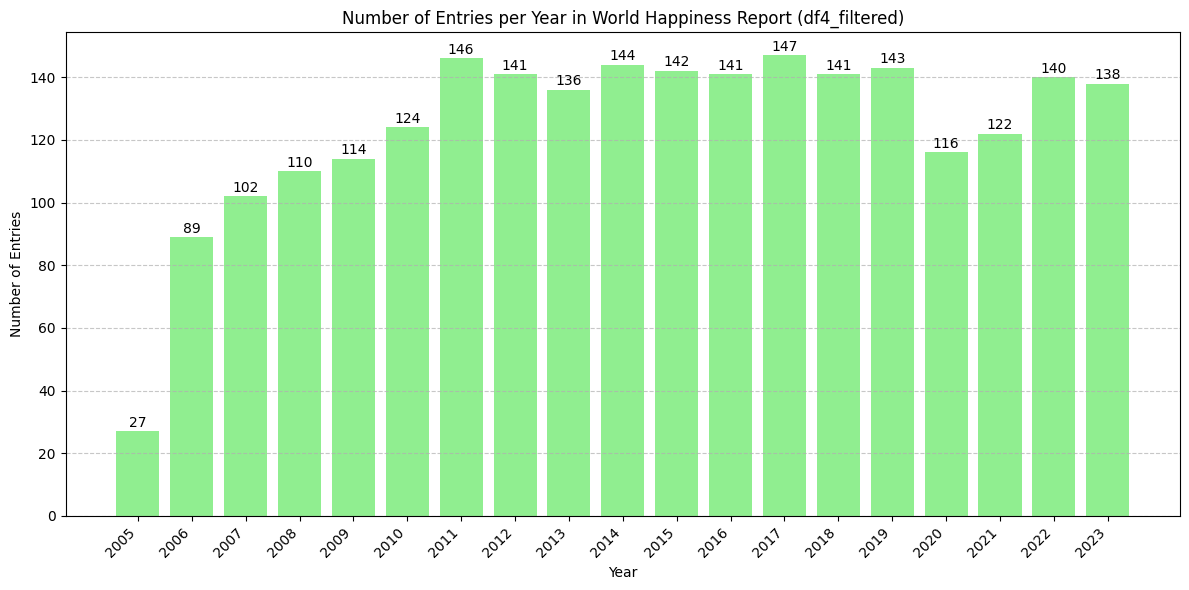

In [18]:
# Count the number of occurrences for each year
year_counts_df4 = df4_filtered['year'].value_counts().sort_index()

# Plotting the bar graph
plt.figure(figsize=(12, 6))
bars = plt.bar(year_counts_df4.index.astype(str), year_counts_df4.values, color='lightgreen')
plt.xlabel('Year')
plt.ylabel('Number of Entries')
plt.title('Number of Entries per Year in World Happiness Report (df4_filtered)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Add value labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, int(yval), ha='center', va='bottom')

plt.show()

After analyzing the frequency of unique years in Dataset 4, we observed that the number of entries varies by year. This indicates that the countries covered in the dataset are not consistently represented across the entire timeline. Given that our main datatset (DS1) only extends to 2017, we should limit our analysis to data prior to 2017 should we choose to use this dataset.

In [19]:
matching_countries_ds1_ds4 = {}

for year in range(2010, 2018):
    countries_df1_year = set(df1[df1['Year'] == year]['Entity'].unique())
    countries_df4_year = set(df4_filtered[df4_filtered['year'] == year]['Country name'].unique())
    matching_countries_ds1_ds4[year] = len(countries_df1_year.intersection(countries_df4_year))


for year, count in matching_countries_ds1_ds4.items():
    print(f"Number of matching countries between DS1 and DS4 for {year}: {count}")

Number of matching countries between DS1 and DS4 for 2010: 116
Number of matching countries between DS1 and DS4 for 2011: 135
Number of matching countries between DS1 and DS4 for 2012: 131
Number of matching countries between DS1 and DS4 for 2013: 127
Number of matching countries between DS1 and DS4 for 2014: 134
Number of matching countries between DS1 and DS4 for 2015: 133
Number of matching countries between DS1 and DS4 for 2016: 131
Number of matching countries between DS1 and DS4 for 2017: 137


After comparing the number of countries that appear in both df1 and df4 from 2010 to 2017, we realized we still have adequate amount of data to perform our analysis. Hence, df1 and df4 seem to be a nice fit for our analysis project.

**Data Quality Considerations**

The following shows some advantages of using this dataset for our analysis:

* The dataset has high level of completeness since there's limited amount of NULL value
* The dataset overlaps with DS1 in terms of geographical coverage, making them a nice fit.
* The dataset is relevant to our research topic and it provides clear distinction between countries with high and low level of happiness.
* The dataset is retrieved from Kaggle, which is a reputated source of dataset.

However, we do acknowledge that this dataset is relatively complex and many indicators may not be closely linked to air quality. Meanwhile, the large variety of data also impose a risk of misunderstanding it too.


**Conclusions for DS4**

After the data exploration, we decide to include this dataset for our subsequent data analysis. However, we will keep in mind the following:

*   We will be required to focus on only the data prior to 2017 to match the timeframe of DS1
*   For the null value, we are required to perform data cleaning later on to ensure that it does not affect the analyze phase.



### DS5: PM2.5 Global Air Pollution Exploration


**Description:**



This Kaggle dataset contains historical air quality data from 2010-2017 for 240 countries. PM2.5 (fine particulate) mean annual exposure is provided in micrograms per cubic meter.

The following provides description of each column value:
* **Country Name:** Name of the country
* **Country Code:** Unique country code for each country
* **PM2.5 Mean Annual Exposure from 2010 to 2017:** Air quality indicator for each country

In [20]:
df5 = pd.read_csv("SC3021 Datasets/PM2.5 Global Air Pollution 2010-2017.csv")

display(df5.head())

,Country Name,Country Code,2010,2011,2012,2013,2014,2015,2016,2017
0,Afghanistan,AFG,65.245592,66.835727,66.023174,61.366745,59.010330,61.252656,56.287047,56.910808
1,Angola,AGO,33.787247,33.104195,33.415495,34.663923,32.974025,32.729873,31.785389,32.388505
2,Albania,ALB,21.277828,22.772537,20.578259,19.938517,18.883955,19.512540,18.189934,18.200603
3,Andorra,AND,12.807197,13.273506,12.407053,11.813673,10.830418,11.462178,10.255834,10.307621
4,Arab World,ARB,53.787001,52.652279,53.297270,54.053822,52.583603,60.406813,58.764905,58.689259


In [21]:
display(df5.isnull().sum())

Country Name    0
Country Code    0
2010            0
2011            0
2012            0
2013            0
2014            0
2015            0
2016            0
2017            0
dtype: int64

It is observed that this dataset contains zero null values, ensuring complete data integrity. This makes it an ideal resource for analyzing air pollution trends over the 2010–2017 period.

In [22]:

unique_country_ds5 = pd.concat([df5['Country Name']]).unique()


print(unique_country_ds5)

total_countries_covered_ds5 = unique_country_ds5.size
print()
print(f"Total countries covered: {total_countries_covered_ds5}")

['Afghanistan' 'Angola' 'Albania' 'Andorra' 'Arab World'
 'United Arab Emirates' 'Argentina' 'Armenia' 'American Samoa'
 'Antigua and Barbuda' 'Australia' 'Austria' 'Azerbaijan' 'Burundi'
 'Belgium' 'Benin' 'Burkina Faso' 'Bangladesh' 'Bulgaria' 'Bahrain'
 'Bahamas, The' 'Bosnia and Herzegovina' 'Belarus' 'Belize' 'Bermuda'
 'Bolivia' 'Brazil' 'Barbados' 'Brunei Darussalam' 'Bhutan' 'Botswana'
 'Central African Republic' 'Canada' 'Central Europe and the Baltics'
 'Switzerland' 'Chile' 'China' "Cote d'Ivoire" 'Cameroon'
 'Congo, Dem. Rep.' 'Congo, Rep.' 'Colombia' 'Comoros' 'Cabo Verde'
 'Costa Rica' 'Caribbean small states' 'Cuba' 'Cyprus' 'Czech Republic'
 'Germany' 'Djibouti' 'Dominica' 'Denmark' 'Dominican Republic' 'Algeria'
 'East Asia & Pacific (excluding high income)'
 'Early-demographic dividend' 'East Asia & Pacific'
 'Europe & Central Asia (excluding high income)' 'Europe & Central Asia'
 'Ecuador' 'Egypt, Arab Rep.' 'Euro area' 'Eritrea' 'Spain' 'Estonia'
 'Ethiopia' 'Europe

After performing a geographical coverage check, we observed that this dataset tends to aggregate certain countries into regions, providing a single row of values for the entire group. Consequently, it is essential to identify and remove these regional entries to ensure our final dataset consists exclusively of individual country-level data.

In [23]:
set_ds1 = set(unique_country_ds1)
set_ds5 = set(unique_country_ds5)

common_countries_ds1_ds5 = set_ds1.intersection(set_ds5)

print(f"Number of common countries between DS1 and DS5: {len(common_countries_ds1_ds5)}")

Number of common countries between DS1 and DS5: 173


It is also observed that this dataset has a significant overlap with our primary dataset (DS1). Even after performing a check based on common countries, the resulting dataset still provides 173 unique countries for evaluation.

**Data Quality Considerations**

Advantages of using this dataset:

* The dataset is relatively reliable, having been sourced from Kaggle.

* It has a significant overlap with our primary dataset, providing substantial support for our research question.

* The data structure is intuitive and easy to interpret.

We observed that this dataset requires a pivoting operation (specifically, a transformation from wide to long format). Currently, individual years are formatted as separate columns; we intend to consolidate these into a single "Year" column to ensure consistency with our other datasets.



**Conclusions for DS5**

Following our data exploration, we have decided to include this dataset in our analysis for the following reasons:

* The timeframe aligns perfectly with Dataset 1, covering the period from 2010 to 2017.

* The dataset provides clear air quality indicators for the specific countries represented in DS1, ensuring a high degree of overlap.

* While the dataset requires a pivoting operation (from wide to long format), the transformation is straightforward to implement and will not hinder our analysis timeline.

### DS6: World Population by Year (1950-2023) Exploration

**Description:**


This kaggle dataset contains the evolution of world populations from 1950 to 2023, with yearly granularity for each country.

The following provides description of each column value:
* **country:** Name of the country
* every year from 1950 to 2023 as a column

In [24]:
df6 = pd.read_csv("SC3021 Datasets/world_population_by_year_1950_2023.csv")

display(df6.head())

,country,1950,1951,1952,1953,1954,1955,1956,1957,1958,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Afghanistan,7480461,7571537,7667533,7764546,7864285,7971931,8087727,8210201,8333826,...,32716210,33753499,34636207,35643418,36686784,37769499,38972230,40099462,41128771,42239854
1,Albania,1252582,1289168,1326948,1366744,1409005,1453730,1500624,1549571,1600983,...,2884102,2882481,2881063,2879355,2877013,2873883,2866849,2854710,2842321,2832439
2,Algeria,9019866,9271734,9521702,9771686,10011541,10242288,10473168,10703251,10933784,...,38760168,39543154,40339329,41136546,41927007,42705368,43451666,44177969,44903225,45606480
3,American Samoa,19032,19425,19561,19670,19758,19826,19902,19937,19918,...,52217,51368,50448,49463,48424,47321,46189,45035,44273,43914
4,Andorra,6005,5827,5454,5308,5566,6116,6705,7330,7994,...,71621,71746,72540,73837,75013,76343,77700,79034,79824,80088


In [25]:
display(df6.isnull().sum())

country    0
1950       0
1951       0
1952       0
1953       0
          ..
2019       0
2020       0
2021       0
2022       0
2023       0
Length: 75, dtype: int64

It is observed that this dataset contains zero null values, ensuring complete data integrity.

This makes it an ideal resource for measuring the total population of each country, where we will be able to determine how many people are affected by the country's air quality.

In [26]:
unique_country_ds6 = pd.concat([df6['country']]).unique()


print(unique_country_ds6)

total_countries_covered_ds6 = unique_country_ds6.size
print()
print(f"Total countries covered: {total_countries_covered_ds6}")

['Afghanistan' 'Albania' 'Algeria' 'American Samoa' 'Andorra' 'Angola'
 'Anguilla' 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Aruba'
 'Australia' 'Austria' 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh'
 'Barbados' 'Belarus' 'Belgium' 'Belize' 'Benin' 'Bermuda' 'Bhutan'
 'Bolivia' 'Bosnia and Herzegovina' 'Botswana' 'Brazil'
 'British Virgin Islands' 'Brunei' 'Bulgaria' 'Burkina Faso' 'Burundi'
 'Cambodia' 'Cameroon' 'Canada' 'Cape Verde' 'Caribbean Netherlands'
 'Cayman Islands' 'Central African Republic' 'Chad' 'Chile' 'China'
 'Colombia' 'Comoros' 'Congo' 'Cook Islands' 'Costa Rica' "Côte d'Ivoire"
 'Croatia' 'Cuba' 'Curaçao' 'Cyprus' 'Czech Republic (Czechia)' 'Denmark'
 'Djibouti' 'Dominica' 'Dominican Republic'
 'Democratic Republic of the Congo' 'Ecuador' 'Egypt' 'El Salvador'
 'Equatorial Guinea' 'Eritrea' 'Estonia' 'Eswatini' 'Ethiopia'
 'Falkland Islands' 'Faroe Islands' 'Fiji' 'Finland' 'France'
 'French Guiana' 'French Polynesia' 'Gabon' 'Gambia' 'Georgia' 'Germany'
 'Ghan

From the above, we can conclude that the geographical coverage of this dataset is adequate for our analysis since it covers many countries from all main continents.

In [27]:
set_ds1 = set(unique_country_ds1)
set_ds6 = set(unique_country_ds6)

common_countries_ds1_ds6 = set_ds1.intersection(set_ds6)

print(f"Number of common countries between DS1 and DS6: {len(common_countries_ds1_ds6)}")

Number of common countries between DS1 and DS6: 184


It is also observed that this dataset has a significant overlap with our primary dataset (DS1). Even after performing a check based on common countries, the resulting dataset still provides 184 unique countries for evaluation.

**Data Quality Considerations**

Advantages of using this dataset:

* The dataset is relatively reliable, having been sourced from Kaggle.

* It has a significant overlap with our primary dataset, providing substantial support for our research question.

* The data structure is intuitive and easy to interpret.

We observed that this dataset requires a pivoting operation (specifically, a transformation from wide to long format). Currently, individual years are formatted as separate columns; we intend to consolidate these into a single "Year" column to ensure consistency with our other datasets.

**Conclusion for DS6**

Following our data exploration, we have decided to include this dataset in our analysis for the following reasons:

* Our dataframe contains the timeframe that aligns perfectly with Dataset 1, covering the period from 2010 to 2017.

* The dataset provides total population of each country, which can be **aggregated** with the "Air pollution (total) (deaths per 100,000)" attribute in Dataset 1 to **enrich** our data

* While the dataset requires a pivoting operation (from wide to long format), the transformation is straightforward to implement and will not hinder our analysis timeline.

## Data Preparation (Process)

### Overview

Our data preparation process can be summarized as the following:

1. Structured DS1, DS4, DS5, and DS6 by filtering irrelevant columns, handling missing values, standardising column headers, and ensuring data type consistency.

2. Transformed DS5 and DS6 from a "wide" format to a "long" format by performing a column-to-row pivoting operation on the year attributes.

3. Executed an inner join to merge DS1, DS4, DS5, and DS6, ensuring only records present across all datasets were retained to maintain data density.

4. Enriched the integrated dataset by deriving a new calculated field, Total Air Pollution Deaths, based on mortality rates and population figures.

5. Conducted a sensitivity analysis on missing value imputation methods to ensure that the chosen handling technique did not bias the final statistical distribution.

![Data Preparation Pipeline](Images/Data_preparation_pipeline.png)

### Structuring data from DS1

**Dropped all the column except total death per 100000 caused by air pollution in DS1**


We are only using the total death for our analysis. Hence, we remove all the other columns as part of a structuring operation.

In [28]:
df1_cleaned = df1.drop(columns=["Code",
                                "Indoor air pollution (deaths per 100,000)",
                                "Outdoor particulate matter (deaths per 100,000)",
                                "Outdoor ozone pollution (deaths per 100,000)"])




**Datatype conversion and renaming column**


We ensured consistency by renaming the 'Entity' column to 'Country Name' to standardize the naming convention across all datasets. We also verified that the data types were correct by converting the air pollution death values to a numeric format.

In [29]:
df1_cleaned["Air pollution (total) (deaths per 100,000)"] = pd.to_numeric(
    df1_cleaned["Air pollution (total) (deaths per 100,000)"],
    errors="coerce"
)

df1_cleaned = df1_cleaned.rename(columns={
    "Entity": "Country name",
})

**Filtering our irrelevant tuples**

We are focusing exclusively on data from 2010 to 2017. Therefore, we filtered the dataset to retain only the records within that timeframe.

In [30]:
df1_final = df1_cleaned[(df1_cleaned["Year"] >= 2010) & (df1_cleaned["Year"] <= 2017)]

In [31]:
df1_final

,Country name,Year,"Air pollution (total) (deaths per 100,000)"
20,Afghanistan,2010,221.525572
21,Afghanistan,2011,214.332694
22,Afghanistan,2012,207.388702
23,Afghanistan,2013,200.905640
24,Afghanistan,2014,195.436958
...,...,...,...
6463,Zimbabwe,2013,143.850145
6464,Zimbabwe,2014,138.200536
6465,Zimbabwe,2015,132.752553
6466,Zimbabwe,2016,128.692138


### Structuring data from DS4

**Dropping irrelevant records from DS4**

Since we are only looking for data between 2010-2017, we will be removing records that are not within that range.

In [32]:
df4_filtered = df4_filtered[df4_filtered['year'].between(2010, 2017)]
display(df4_filtered.head())

df4_filtered = df4_filtered.rename(columns={
    "year": "Year",
})

,Country name,year,Log GDP per capita,Healthy life expectancy at birth
2,Afghanistan,2010,7.614,51.1
3,Afghanistan,2011,7.581,51.4
4,Afghanistan,2012,7.661,51.7
5,Afghanistan,2013,7.680,52.0
6,Afghanistan,2014,7.671,52.3


**Dealing with missing values**

We will be applying the concept of Data Imputation for missing values in the GDP and Life expectancy columns by calculating the average log GDP/Life expectancy using the country's records within that year range and using it to fill in the missing values.  

In [33]:
print("\nNumber of null values per column:")
display(df4_filtered.isnull().sum())

countries_with_na = df4_filtered[df4_filtered.isna().any(axis=1)]['Country name'].unique()

countries_to_review = df4_filtered[df4_filtered['Country name'].isin(countries_with_na)]

print(f"Found {len(countries_with_na)} countries with missing values.")
display(countries_to_review)



Number of null values per column:


Country name                         0
Year                                 0
Log GDP per capita                   7
Healthy life expectancy at birth    32
dtype: int64

Found 6 countries with missing values.


,Country name,Year,Log GDP per capita,Healthy life expectancy at birth
849,Hong Kong S.A.R. of China,2010,10.847,NaN
850,Hong Kong S.A.R. of China,2011,10.887,NaN
851,Hong Kong S.A.R. of China,2012,10.893,NaN
852,Hong Kong S.A.R. of China,2014,10.939,NaN
853,Hong Kong S.A.R. of China,2016,10.970,NaN
854,Hong Kong S.A.R. of China,2017,10.999,NaN
1103,Kosovo,2010,8.940,NaN
1104,Kosovo,2011,8.992,NaN
1105,Kosovo,2012,9.000,NaN
1106,Kosovo,2013,9.046,NaN


### Pivoting DS5 and DS6

**Structuring DS5 and perform column to row pivoting**

Since DS5 uses the years 2010 through 2017 as column headers, we performed a pivoting operation (unpivoting) to transform these columns into rows. Additionally, we restructured the data by renaming fields, dropping irrelevant columns, and updating data types.

In [34]:
df5_long = df5.melt(
    id_vars=["Country Name", "Country Code"],
    value_vars=["2010", "2011", "2012", "2013", "2014", "2015", "2016", "2017"],
    var_name="Year",
    value_name="PM2.5"
)

df5_long["Year"] = df5_long["Year"].astype(int)

df5_long = df5_long.rename(columns={
    "Country Name": "Country name",
})

df5_final = df5_long.drop(columns=["Country Code"])



In [35]:
df5_final

,Country name,Year,PM2.5
0,Afghanistan,2010,65.245592
1,Angola,2010,33.787247
2,Albania,2010,21.277828
3,Andorra,2010,12.807197
4,Arab World,2010,53.787001
...,...,...,...
1915,Samoa,2017,11.548027
1916,"Yemen, Rep.",2017,50.456007
1917,South Africa,2017,25.102205
1918,Zambia,2017,27.438035


**Structuring DS6 and perform column to row pivoting**

Similar to DS5, DS6 uses years as column headers. Because DS6 spans from 1950 to 2023, we first filtered the data to retain only the years 2010 through 2017.

In [36]:
years_to_keep = [str(year) for year in range(2010, 2018)]
df6_filtered = df6[["country"] + years_to_keep]

We then performed a pivoting operation (unpivoting) to transform these columns into rows. We also performed datatype conversion to ensure consistency.

In [37]:
df6_long = (
    df6_filtered
    .set_index("country")
    .stack()
    .reset_index()
)


df6_long.columns = ["Country name", "Year", "Population"]


df6_long["Year"] = df6_long["Year"].astype(int)

df6_final = df6_long

In [38]:
df6_final

,Country name,Year,Population
0,Afghanistan,2010,28189672
1,Afghanistan,2011,29249157
2,Afghanistan,2012,30466479
3,Afghanistan,2013,31541209
4,Afghanistan,2014,32716210
...,...,...,...
1867,Zimbabwe,2013,13555422
1868,Zimbabwe,2014,13855753
1869,Zimbabwe,2015,14154937
1870,Zimbabwe,2016,14452704


### Inner join DS1, DS4, DS5, DS6

**Inner Join Operation**

We performed an inner join to combine the relevant columns from DS1, DS4, DS5, and DS6 into a final dataset for analysis. An inner join was selected because DS5 includes regional aggregates under the 'Country Name' column that are absent from the other datasets. Using alternative joining techniques would have introduced a significant number of null values. We use "Country name" and "Year" columns as our join key.

In [39]:
df_final = (
    df1_final
    .merge(df4_filtered, on=['Country name', 'Year'], how='inner')
    .merge(df5_final, on=['Country name', 'Year'], how='inner')
    .merge(df6_final, on=['Country name', 'Year'], how='inner')
)

df_final



,Country name,Year,"Air pollution (total) (deaths per 100,000)",Log GDP per capita,Healthy life expectancy at birth,PM2.5,Population
0,Afghanistan,2010,221.525572,7.614,51.100,65.245592,28189672
1,Afghanistan,2011,214.332694,7.581,51.400,66.835727,29249157
2,Afghanistan,2012,207.388702,7.661,51.700,66.023174,30466479
3,Afghanistan,2013,200.905640,7.680,52.000,61.366745,31541209
4,Afghanistan,2014,195.436958,7.671,52.300,59.010330,32716210
...,...,...,...,...,...,...,...
967,Zimbabwe,2013,143.850145,7.755,48.800,23.111088,13555422
968,Zimbabwe,2014,138.200536,7.748,50.000,22.805950,13855753
969,Zimbabwe,2015,132.752553,7.747,51.200,21.733709,14154937
970,Zimbabwe,2016,128.692138,7.735,51.675,21.726947,14452704


**Removing null values under "Log GDP per capita""**

We then apply data imputation to rectify the null values for "Log GDP per capita" column in the final dataset

In [40]:
unique_countries = pd.concat([df_final['Country name']]).unique()
total_countries_covered = unique_countries.size
print()
print(f"Total countries covered: {total_countries_covered}")

df_final["Log GDP per capita"] = df_final["Log GDP per capita"].fillna(df_final.groupby("Country name")["Log GDP per capita"].transform("mean"))
print("\nNumber of null values per column:")

df_final = df_final.dropna(subset=['Log GDP per capita'])

df_final = df_final.reset_index(drop=True)

display(df_final.isnull().sum())


Total countries covered: 139

Number of null values per column:


Country name                                  0
Year                                          0
Air pollution (total) (deaths per 100,000)    0
Log GDP per capita                            0
Healthy life expectancy at birth              0
PM2.5                                         0
Population                                    0
dtype: int64

### Enrichment of joined dataset

**Calculating new data field**

We used the 'Air pollution (total) (deaths per 100,000)' and 'Population' fields to calculate a new column, 'Total Air Pollution Deaths,' which was added to the final dataset. This column was derived using the following formula:

$$\text{Total Air Pollution Deaths} = \left( \frac{\text{Air Pollution (deaths per 100,000)}}{100,000} \right) \times \text{Population}$$

In [41]:
df_final = df_final.round({"Air pollution (total) (deaths per 100,000)":3, "Log GDP per capita":3, "Healthy life expectancy at birth":1})
df_final['Population'] = df_final['Population'].astype(int)
df_final["Total air pollution deaths"] = (
    df_final["Air pollution (total) (deaths per 100,000)"] * df_final["Population"] / 100000
)

In [42]:
df_final

,Country name,Year,"Air pollution (total) (deaths per 100,000)",Log GDP per capita,Healthy life expectancy at birth,PM2.5,Population,Total air pollution deaths
0,Afghanistan,2010,221.526,7.614,51.1,65.245592,28189672,62447.452795
1,Afghanistan,2011,214.333,7.581,51.4,66.835727,29249157,62690.595673
2,Afghanistan,2012,207.389,7.661,51.7,66.023174,30466479,63184.126133
3,Afghanistan,2013,200.906,7.680,52.0,61.366745,31541209,63368.181354
4,Afghanistan,2014,195.437,7.671,52.3,59.010330,32716210,63939.579338
...,...,...,...,...,...,...,...,...
963,Zimbabwe,2013,143.850,7.755,48.8,23.111088,13555422,19499.474547
964,Zimbabwe,2014,138.201,7.748,50.0,22.805950,13855753,19148.789204
965,Zimbabwe,2015,132.753,7.747,51.2,21.733709,14154937,18791.103516
966,Zimbabwe,2016,128.692,7.735,51.7,21.726947,14452704,18599.473832


### Sensitivity check for joined dataset

**Justification of missing value handling through sensitivity test**

To ensure the integrity of our findings, we conducted a sensitivity analysis (robustness check) on the 'Log GDP per capita' variable using three methods: mean imputation, listwise deletion, and linear interpolation. 

In [43]:
df_base = df_final.copy()
df_mean = df_base.copy()
df_mean["Log GDP per capita"] = df_mean["Log GDP per capita"].fillna(
    df_mean.groupby("Country name")["Log GDP per capita"].transform("mean")
)
df_mean = df_mean.dropna(subset=['Log GDP per capita'])

df_dropped = df_base.copy()
df_dropped = df_dropped.dropna(subset=['Log GDP per capita'])

df_interpolated = df_base.copy()
df_interpolated["Log GDP per capita"] = df_interpolated.groupby("Country name")["Log GDP per capita"].transform(
    lambda x: x.interpolate(method='linear', limit_direction='both')
)
df_interpolated = df_interpolated.dropna(subset=['Log GDP per capita']) 

comparison = pd.DataFrame({
    "Mean": df_mean["Log GDP per capita"].describe(),
    "Dropped Nulls": df_dropped["Log GDP per capita"].describe(),
    "Interpolated": df_interpolated["Log GDP per capita"].describe()
})

print(comparison)

             Mean  Dropped Nulls  Interpolated
count  968.000000     968.000000    968.000000
mean     9.391998       9.391998      9.391998
std      1.162474       1.162474      1.162474
min      6.694000       6.694000      6.694000
25%      8.477000       8.477000      8.477000
50%      9.476500       9.476500      9.476500
75%     10.369500      10.369500     10.369500
max     11.664000      11.664000     11.664000


We realised that countries with null values have null values for every year, therefore methods like linear interpolation and mean would be no different than removing the null values.

## Data Analysis (Analyze)

Given that our ovarching goal is to determine if there is a relationship between air pollution and life expectancy, we apply the following concepts from data analytics:

*   Visualization (Descriptive analysis)
*   Relationship and dependency analysis (Diagnostic analysis)
*   Hypothesis testing and validation (Diagnostic analysis)
*   Linear regression model (Predictive analysis)

### Visualization

**Goal:** The goal is to visually describe the distribution of scores for the different climate zones.

**Methods / measures:** We will create a categorical variable "Severity of Air Pollution" and classify each country "Low", "Moderate" and "High" based on their air pollution levels (PM2.5). Then, we use box plots as compact visualization of each distribution.

**Code:** For each severity level, we generate a box plot.

In [44]:
df_avg = (
    df_final.groupby("Country name", as_index=False)
    .agg({
        "Air pollution (total) (deaths per 100,000)": "mean",
        "Log GDP per capita": "mean",
        "Healthy life expectancy at birth": "mean",
        "PM2.5": "mean",
        "Population": "mean",
        "Total air pollution deaths": "mean"
    })
    .rename(columns={
        "Air pollution (total) (deaths per 100,000)": "Avg deaths per 100,000",
        "Log GDP per capita": "Avg log GDP per capita",
        "Healthy life expectancy at birth": "Avg healthy life expectancy",
        "PM2.5": "Avg PM2.5",
        "Population": "Avg population",
        "Total air pollution deaths": "Avg total air pollution deaths"
    })
)

print(df_avg.head())

  Country name  Avg deaths per 100,000  Avg log GDP per capita  \
0  Afghanistan              200.250250                7.644875   
1      Albania               43.040125                9.358625   
2      Algeria               45.175333                9.344500   
3       Angola              111.201000                8.985750   
4    Argentina               34.410875               10.080250   

   Avg healthy life expectancy  Avg PM2.5  Avg population  \
0                    52.150000  61.616510    3.202448e+07   
1                    68.475000  19.919271    2.890033e+06   
2                    65.833333  35.856316    3.831608e+07   
3                    52.150000  33.539409    2.568069e+07   
4                    66.700000  15.267052    4.259568e+07   

   Avg total air pollution deaths  
0                    63823.425582  
1                     1244.043855  
2                    17291.028823  
3                    28499.965767  
4                    14635.046166  


In [45]:
df_avg = df_avg.sort_values("Avg PM2.5").reset_index(drop=True)

low_idx, moderate_idx, high_idx = np.array_split(df_avg.index, 3)

df_avg["PM25_Category"] = ""

df_avg.loc[low_idx, "PM25_Category"] = "Low"
df_avg.loc[moderate_idx, "PM25_Category"] = "Moderate"
df_avg.loc[high_idx, "PM25_Category"] = "High"

print(len(df_avg))
print(df_avg["PM25_Category"].value_counts())
print(df_avg[df_avg["PM25_Category"] == ""])

138
PM25_Category
Low         46
Moderate    46
High        46
Name: count, dtype: int64
Empty DataFrame
Columns: [Country name, Avg deaths per 100,000, Avg log GDP per capita, Avg healthy life expectancy, Avg PM2.5, Avg population, Avg total air pollution deaths, PM25_Category]
Index: []


#### PM2.5 against Deaths

C:\Users\damie\AppData\Local\Temp\ipykernel_34344\719966765.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([low_deaths, moderate_deaths, high_deaths], labels=["Low", "Moderate", "High"])


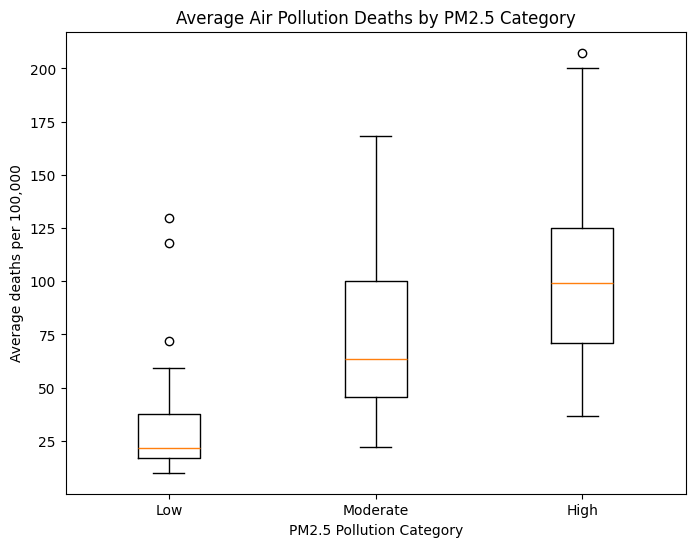

In [46]:
low_deaths = df_avg[df_avg["PM25_Category"] == "Low"]["Avg deaths per 100,000"]
moderate_deaths = df_avg[df_avg["PM25_Category"] == "Moderate"]["Avg deaths per 100,000"]
high_deaths = df_avg[df_avg["PM25_Category"] == "High"]["Avg deaths per 100,000"]

plt.figure(figsize=(8, 6))
plt.boxplot([low_deaths, moderate_deaths, high_deaths], labels=["Low", "Moderate", "High"])
plt.xlabel("PM2.5 Pollution Category")
plt.ylabel("Average deaths per 100,000")
plt.title("Average Air Pollution Deaths by PM2.5 Category")
plt.show()

**Interpretation** Through this boxplots, we can see that there is a positive relationship between PM2.5 levels and average deaths per 100,000. The medians of average deaths is significantly different from "Low", "Moderate" and "High" pollution. Furthurmore, the interquartile range of the "Low" air pollution category is much smaller compared to "Moderate" and "High", which further suggests that a large majority of countries with low PM2.5 levels has a low death rate.

#### PM2.5 against log GDP per capita

C:\Users\damie\AppData\Local\Temp\ipykernel_34344\2831893500.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([low_gdp, moderate_gdp, high_gdp], labels=["Low", "Moderate", "High"])


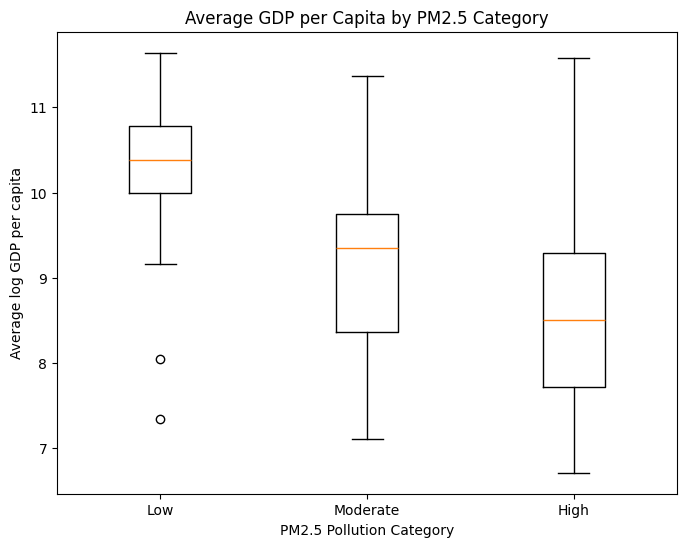

In [47]:
low_gdp = df_avg[df_avg["PM25_Category"] == "Low"]["Avg log GDP per capita"]
moderate_gdp = df_avg[df_avg["PM25_Category"] == "Moderate"]["Avg log GDP per capita"]
high_gdp = df_avg[df_avg["PM25_Category"] == "High"]["Avg log GDP per capita"]

plt.figure(figsize=(8, 6))
plt.boxplot([low_gdp, moderate_gdp, high_gdp], labels=["Low", "Moderate", "High"])
plt.xlabel("PM2.5 Pollution Category")
plt.ylabel("Average log GDP per capita")
plt.title("Average GDP per Capita by PM2.5 Category")
plt.show()

**Interpretation** We can also see there are other factors that have a relationship with air pollution. log GDP per capita and PM2.5 levels has a negative relationship, which indicates that a country's economy is also related to air pollution. This could be due to better infrastructure that has developed cleaner energy sources.

#### PM2.5 against Life Expectancy at Birth

C:\Users\damie\AppData\Local\Temp\ipykernel_34344\501244159.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([low_life, moderate_life, high_life], labels=["Low", "Moderate", "High"])


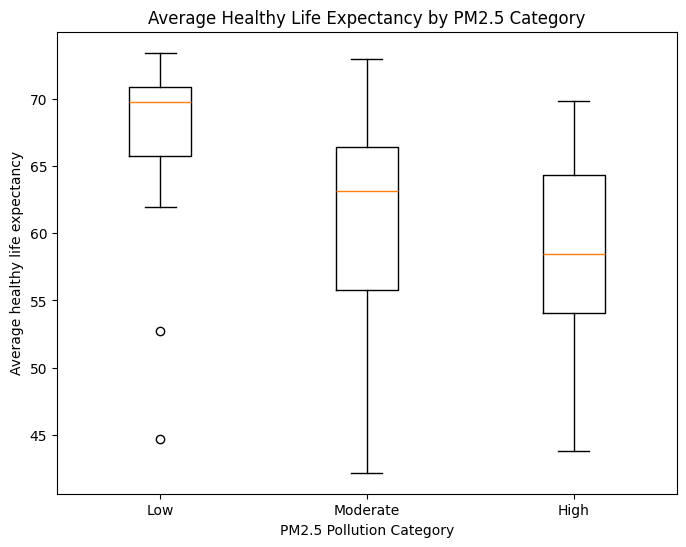

In [48]:
low_life = df_avg[df_avg["PM25_Category"] == "Low"]["Avg healthy life expectancy"]
moderate_life = df_avg[df_avg["PM25_Category"] == "Moderate"]["Avg healthy life expectancy"]
high_life = df_avg[df_avg["PM25_Category"] == "High"]["Avg healthy life expectancy"]

plt.figure(figsize=(8, 6))
plt.boxplot([low_life, moderate_life, high_life], labels=["Low", "Moderate", "High"])
plt.xlabel("PM2.5 Pollution Category")
plt.ylabel("Average healthy life expectancy")
plt.title("Average Healthy Life Expectancy by PM2.5 Category")
plt.show()

**Interpretation** Here, we also see a negative relationship between air pollution and life expectancy. We could interpret that having lower pollution levels lead to a lower risk of chronic diseases such as lung cancer and asthma, which allows the country's citizens to live healthier for long periods of time.

### Relationship and dependency analysis

**Goal.**

The goal is to identify if there is a relationship between air pollution, economic wealth, and life expectancy across independent countries.

<br>

**Methods / measures.**

To ensure the statistical assumption of independence, we first aggregate the 2010–2017 data by calculating a single average for each country. We then apply a correlation analysis. Given that we are not dealing with strictly normally distributed data, and considering the type and distribution of the variables, the Spearman correlation test is the more appropriate choice.

For each pair of variables tested, we define the following hypotheses:

$H_0$ : There is no statistically significant monotonic relationship (correlation) between the two variables ($\rho = 0$).

$H_1$ : There is a statistically significant monotonic relationship (correlation) between the two variables ($\rho \neq 0$).

<br>

**Code.** 

The following code aggregates the data by country and computes the Spearman correlation between PM2.5, Log GDP per capita, Air pollution (total) (deaths per 100,000), and healthy life expectancy at birth.

In [49]:
cols = ['Healthy life expectancy at birth', 'PM2.5', 'Log GDP per capita', 'Air pollution (total) (deaths per 100,000)']
df_subset = df_final.groupby('Country name')[cols].mean()

spearman_matrix = df_subset.corr(method='spearman')
print("Spearman Correlation Matrix:")
display(spearman_matrix)


pairs = [('Healthy life expectancy at birth', 'PM2.5'), 
         ('Healthy life expectancy at birth', 'Log GDP per capita'), 
         ('Healthy life expectancy at birth', 'Air pollution (total) (deaths per 100,000)'), 
         ('PM2.5', 'Log GDP per capita'),
         ('PM2.5', 'Air pollution (total) (deaths per 100,000)'), 
         ('Log GDP per capita', 'Air pollution (total) (deaths per 100,000)')]

for col1, col2 in pairs:
    stat, p_value = stats.spearmanr(df_subset[col1], df_subset[col2])
    
    print(f"\n--- {col1}  VS  {col2} ---")
    print(f"Correlation (r): {stat:.4f}")
    print(f"P-value:         {p_value:.4e}")

Spearman Correlation Matrix:


,Healthy life expectancy at birth,PM2.5,Log GDP per capita,"Air pollution (total) (deaths per 100,000)"
Healthy life expectancy at birth,1.000000,-0.602347,0.849375,-0.918750
PM2.5,-0.602347,1.000000,-0.566601,0.727349
Log GDP per capita,0.849375,-0.566601,1.000000,-0.855275
"Air pollution (total) (deaths per 100,000)",-0.918750,0.727349,-0.855275,1.000000



--- Healthy life expectancy at birth  VS  PM2.5 ---
Correlation (r): -0.6023
P-value:         5.4813e-15

--- Healthy life expectancy at birth  VS  Log GDP per capita ---
Correlation (r): 0.8494
P-value:         1.4410e-39

--- Healthy life expectancy at birth  VS  Air pollution (total) (deaths per 100,000) ---
Correlation (r): -0.9187
P-value:         9.6363e-57

--- PM2.5  VS  Log GDP per capita ---
Correlation (r): -0.5666
P-value:         4.3674e-13

--- PM2.5  VS  Air pollution (total) (deaths per 100,000) ---
Correlation (r): 0.7273
P-value:         5.4072e-24

--- Log GDP per capita  VS  Air pollution (total) (deaths per 100,000) ---
Correlation (r): -0.8553
P-value:         1.1745e-40


**Interpretation.**

1. Statistical Significance (P-Values)

Every single p-value in this analysis is exceptionally small. Using the standard significance level ($\alpha = 0.05$), since all p-values are well below 0.05, we can confidently reject the null hypothesis that there is no relationship between these pairs of factors. 

We can conclude with high statistical certainty that all of these factors are correlated with one another.

<br>

2. Correlation Analysis ($r$-values)

* Life Expectancy vs Air Pollution Death Rate (r = -0.9187): 
    * As the rate of people dying from air pollution increases, the overall healthy life expectancy of the country sharply decreases.

* PM2.5 vs Air Pollution Death Rate (r = 0.7273): 
    * As PM2.5 levels increase, the rate of people dying from air pollution reliably increases.

* PM2.5 vs Life Expectancy (r = -0.6023): 
    * Higher PM2.5 pollution levels directly result in shorter healthy life expectancies.

* GDP vs. Life Expectancy (r = 0.8494): 
    * Wealthier nations (measured by a higher Log GDP per capita) have vastly higher healthy life expectancies.

* GDP vs. Air Pollution Death Rate (r = -0.8553): 
    * Wealthy nations suffer significantly fewer deaths attributed to air pollution.

* GDP vs. PM2.5 (r = -0.5666): 
    * As countries become wealthier, their physical PM2.5 air pollution levels drop.

**Limitations**

The Spearman test only measures how these variables move together; it does not prove that a change in one directly causes a change in the other. For instance, a high GDP does not directly increase life expectancy. Rather, it enables investments in better healthcare, which is the actual direct cause of longer lives. Hence, further tests might be needed to confirm the impact of PM2.5 on life expectancy.

### Hypothesis testing and validation

**Goal.**

The goal is to determine if there is a statistically significant difference in healthy life expectancy between low-pollution and high-pollution countries. 

Meanwhile, we also want to test whether a country's pollution level is indicative of its wealth level by observing the difference in Log GDP per capita between the two groups.

<br>

**Methods / measures.**

To ensure the statistical assumption of independence, we first aggregate the 2010–2017 data by calculating a single average for each country. Because our data is not strictly normally distributed, we apply two Mann-Whitney U Tests (a non-parametric alternative to the independent t-test) which compares the median distributions rather than the means. We establish a dividing line using the global median PM2.5 value and run two separate tests:

1. Comparing the healthy life expectancy of the Low vs. High pollution groups.
    * $H_0$ (Health): There is no statistically significant difference in median healthy life expectancy between countries with high PM2.5 and low PM2.5.

    * $H_1$ (Health): There is a statistically significant difference in median healthy life expectancy between countries with high PM2.5 and low PM2.5.

2. Comparing the Log GDP per capita of the Low vs. High pollution groups to see if economic wealth is tied to these pollution categories.

    * $H_0$(Wealth): There is no statistically significant difference in median Log GDP per capita between countries with high PM2.5 and low PM2.5.

    * $H_1$(Wealth): There is a statistically significant difference in median Log GDP per capita between countries with high PM2.5 and low PM2.5.

<br>

**Code.** 

The following Python code aggregates the dataset by country and plots the distribution of them to show that they are not normally distributed.

It then splits the data into two independent groups and computes the U-statistics and p-values for both the health and economic comparisons using the Mann-Whitney U test.

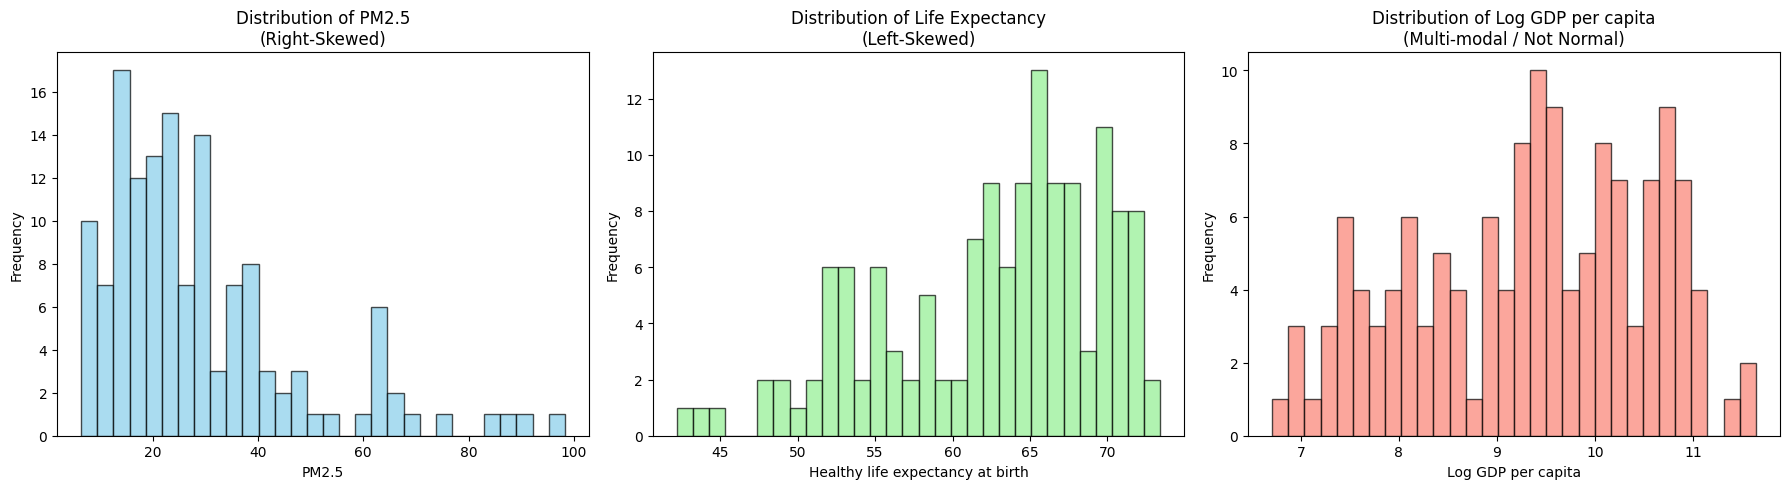

In [50]:
df_agg = df_final.groupby('Country name')[['PM2.5', 'Healthy life expectancy at birth', 'Log GDP per capita']].mean()

df_subset = df_agg[['PM2.5', 'Healthy life expectancy at birth', 'Log GDP per capita']].dropna()


fig, axes = plt.subplots(1, 3, figsize=(18, 5))


axes[0].hist(df_subset['PM2.5'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of PM2.5\n(Right-Skewed)')
axes[0].set_xlabel('PM2.5')
axes[0].set_ylabel('Frequency')

axes[1].hist(df_subset['Healthy life expectancy at birth'], bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribution of Life Expectancy\n(Left-Skewed)')
axes[1].set_xlabel('Healthy life expectancy at birth')
axes[1].set_ylabel('Frequency')

axes[2].hist(df_subset['Log GDP per capita'], bins=30, color='salmon', edgecolor='black', alpha=0.7)
axes[2].set_title('Distribution of Log GDP per capita\n(Multi-modal / Not Normal)')
axes[2].set_xlabel('Log GDP per capita')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [51]:
median_pm25 = df_subset['PM2.5'].median()


low_pollution = df_subset[df_subset['PM2.5'] <= median_pm25]
high_pollution = df_subset[df_subset['PM2.5'] > median_pm25]


u_stat_life, p_val_life = stats.mannwhitneyu(
    low_pollution['Healthy life expectancy at birth'], 
    high_pollution['Healthy life expectancy at birth'], 
    alternative='two-sided'
)


u_stat_gdp, p_val_gdp = stats.mannwhitneyu(
    low_pollution['Log GDP per capita'], 
    high_pollution['Log GDP per capita'], 
    alternative='two-sided'
)


print(f"Median PM2.5 Threshold: {median_pm25:.2f} μg/m³\n")

print("--- Mann-Whitney Test 1: Healthy Life Expectancy ---")
print(f"Low Pollution Median Life Expectancy: {low_pollution['Healthy life expectancy at birth'].median():.2f} years")
print(f"High Pollution Median Life Expectancy: {high_pollution['Healthy life expectancy at birth'].median():.2f} years")
print(f"P-value: {p_val_life:.4e}\n")

print("--- Mann-Whitney Test 2: Log GDP per capita ---")
print(f"Low Pollution Median GDP (Log): {low_pollution['Log GDP per capita'].median():.2f}")
print(f"High Pollution Median GDP (Log): {high_pollution['Log GDP per capita'].median():.2f}")
print(f"P-value: {p_val_gdp:.4e}")

Median PM2.5 Threshold: 24.09 μg/m³

--- Mann-Whitney Test 1: Healthy Life Expectancy ---
Low Pollution Median Life Expectancy: 67.74 years
High Pollution Median Life Expectancy: 60.14 years
P-value: 2.7005e-10

--- Mann-Whitney Test 2: Log GDP per capita ---
Low Pollution Median GDP (Log): 10.12
High Pollution Median GDP (Log): 8.90
P-value: 4.7663e-09


**Interpretation.**

Using a global median PM2.5 threshold of 24.09 $\mu g/m^3$, both tests yielded highly significant results:
<br>

Health Impact ($p = 2.70 \times 10^{-10}$): 

We reject the null hypothesis for health. There is a massive, statistically significant gap in lifespan. Countries in the low-pollution group live a median of 67.74 years, while those in the high-pollution group live only 60.14 years.
<br>

Economic Impact ($p = 4.76 \times 10^{-9}$): 

We also reject the null hypothesis for wealth. The low-pollution group has a significantly higher median Log GDP per capita (10.12) compared to the high-pollution group (8.90).


**Limitations**

Converting a continuous variable like PM2.5 into binary "High vs. Low" buckets oversimplifies the data. A country with a PM2.5 of 24.08 is placed in the "Low" group, while a country with 24.10 is in the "High" group, despite having nearly identical air quality. 

### Linear regression model

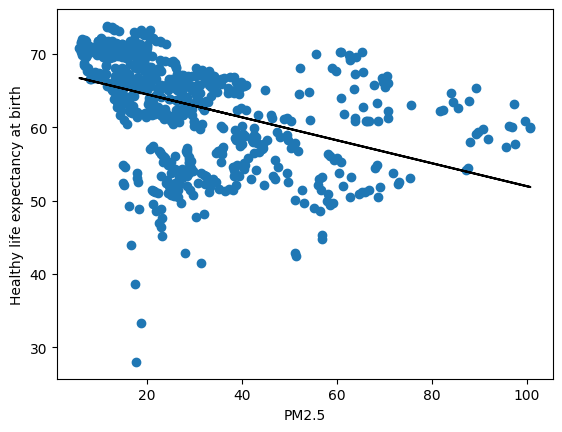

In [52]:
model = LinearRegression()
x_train, x_test, y_train, y_test = train_test_split(df_final[["PM2.5"]], df_final["Healthy life expectancy at birth"], test_size = 0.25)

slope, intercept, r, p, std_err = stats.linregress(x_train["PM2.5"], y_train)
def myfunc(x):
  return slope * x + intercept

linreg = list(map(myfunc, x_train["PM2.5"]))

plt.scatter(x_train["PM2.5"], y_train)
plt.xlabel("PM2.5")
plt.ylabel("Healthy life expectancy at birth")
plt.plot(x_train["PM2.5"], linreg, color = 'k')
plt.show()

In [53]:
model.fit(x_train, y_train)
test_predictions = model.predict(x_test)
test_errors = y_test - test_predictions
print("Test errors:")
print(test_errors)
r2_test = model.score(x_test, y_test)
print("Test R-squared: ", r2_test)

Test errors:
724     4.050052
360   -11.900162
131   -10.818760
172    -3.753139
243     6.971857
         ...    
18      3.305824
710    -2.356009
279     0.412944
734    10.107909
444     7.595278
Name: Healthy life expectancy at birth, Length: 242, dtype: float64
Test R-squared:  0.1789773753845355


In [54]:
X = df_final[["PM2.5"]]
y = df_final["Healthy life expectancy at birth"]

results = []
highest = 0
best_x_train = None
best_y_train = None
best_x_test = None
best_y_test = None

for i in range(100):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=100 + i
    )
    model = LinearRegression()
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    results.append(score)
    if score > highest:
        best_x_train, best_x_test, best_y_train, best_x_test = X_train, X_test, y_train, y_test

for i in results:
    if i > highest:
        highest = i
print("Mean R2:", np.mean(results))
print("Std R2:", np.std(results))
print("Highest R2: ", highest)

Mean R2: 0.17611814756018798
Std R2: 0.04263914270465383
Highest R2:  0.2760876636995646


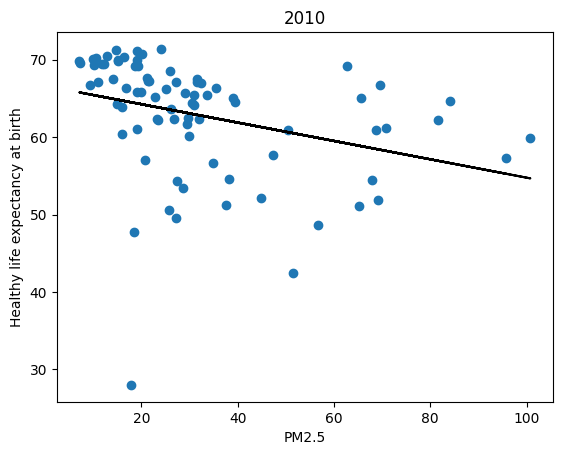

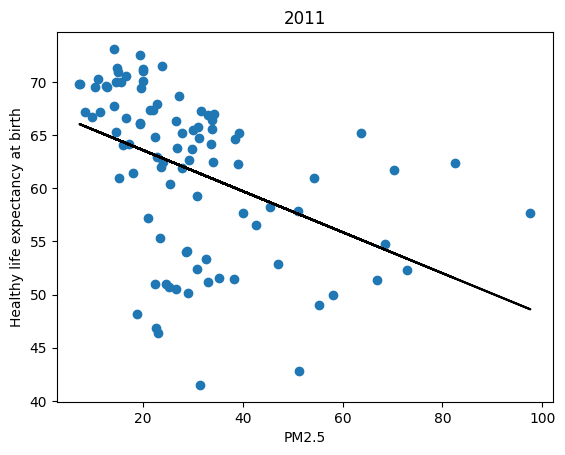

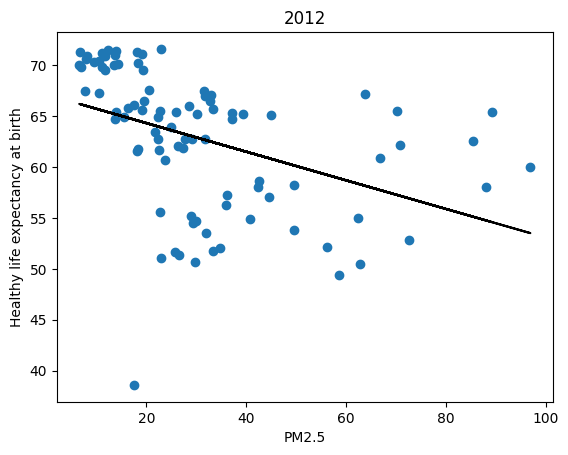

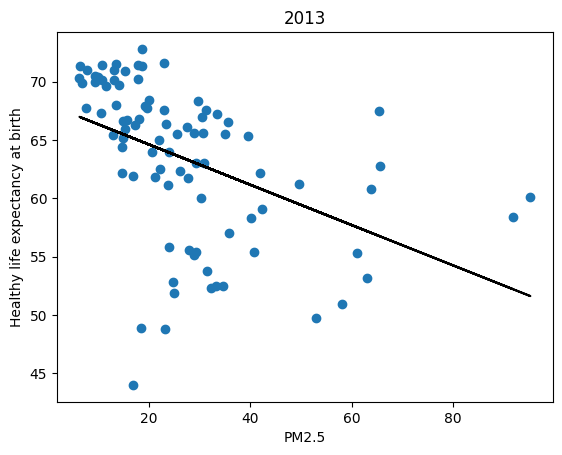

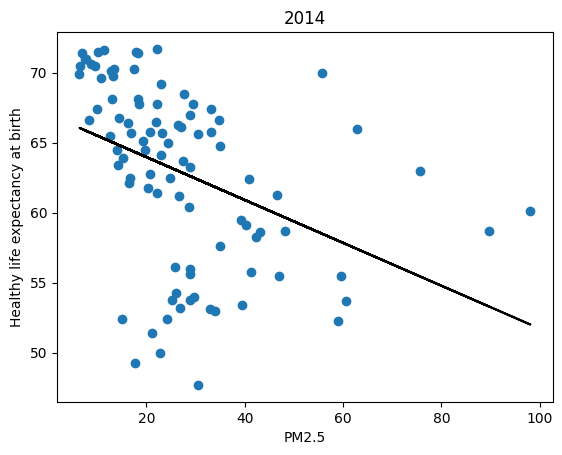

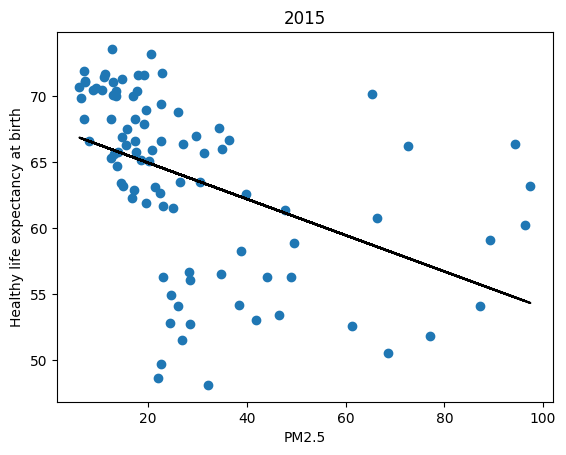

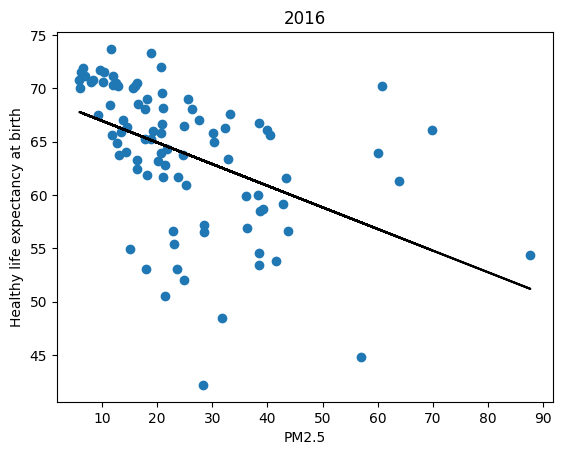

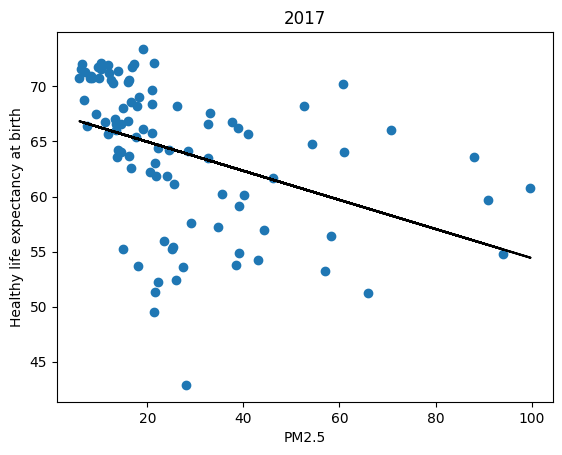

In [55]:
unique_years = df_final["Year"].unique()

for year in unique_years:
    
    df_year = df_final[df_final["Year"] == year]
    
    x_train, x_test, y_train, y_test = train_test_split(df_year[["PM2.5"]], df_year["Healthy life expectancy at birth"], test_size=0.25)

    slope, intercept, r, p, std_err = stats.linregress(x_train["PM2.5"], y_train)
    
    def myfunc(x):
      return slope * x + intercept

    linreg = list(map(myfunc, x_train["PM2.5"]))

    plt.scatter(x_train["PM2.5"], y_train)
    plt.title(year)
    plt.xlabel("PM2.5")
    plt.ylabel("Healthy life expectancy at birth")
    plt.plot(x_train["PM2.5"], linreg, color = 'k')
    plt.show()

From the linear regression analysis, we can conclude that there is a negative correlation between PM2.5 levels and Healthy life expectancy at birth. The mean R-squared value of our model after 100 different training/test data splits was 0.176, with the highest R-squared value being 0.276. An R-squared value of 0.176 indicates that PM2.5 levels accounts for approximately 17.6% of the variance in health expectancy. Considering the fact that our model did not take factors such as GDP and healthcare access, the trend is significant and similar across the 8 years of data. The lines of best fit generally starts around 70–75 healthy life years at the lowest PM2.5 levels, and drops to around 50–55 years as PM2.5 approaches 80–100 units.

## Presentation of main results (Share)

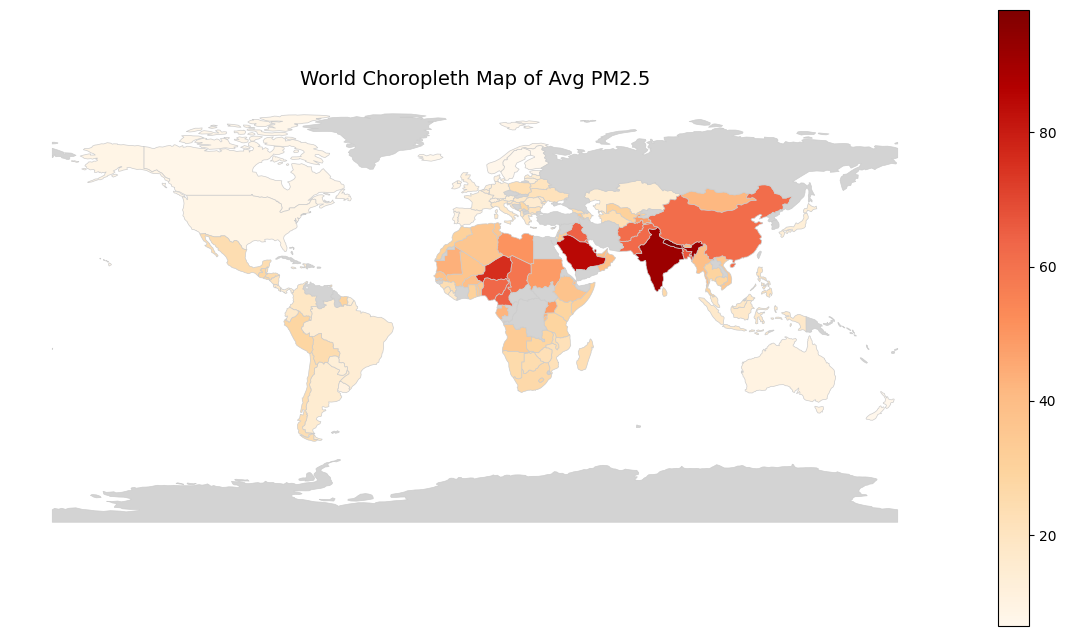

In [56]:
df_map = df_avg

df_map["Country name"] = df_map["Country name"].replace({
    "United States": "United States of America",
    "Democratic Republic of the Congo": "Dem. Rep. Congo",
    "Republic of the Congo": "Congo",
    "Czech Republic": "Czechia",
    "South Sudan": "S. Sudan"
})

world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")

merged = world.merge(
    df_map,
    left_on="NAME",
    right_on="Country name",
    how="left"
)

col_to_plot = "Avg PM2.5"

fig, ax = plt.subplots(figsize=(15, 8))
merged.plot(
    column=col_to_plot,
    cmap="OrRd",
    linewidth=0.5,
    edgecolor="0.8",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "No data"}
)

ax.set_title(f"World Choropleth Map of {col_to_plot}", fontsize=14)
ax.axis("off")
plt.show()

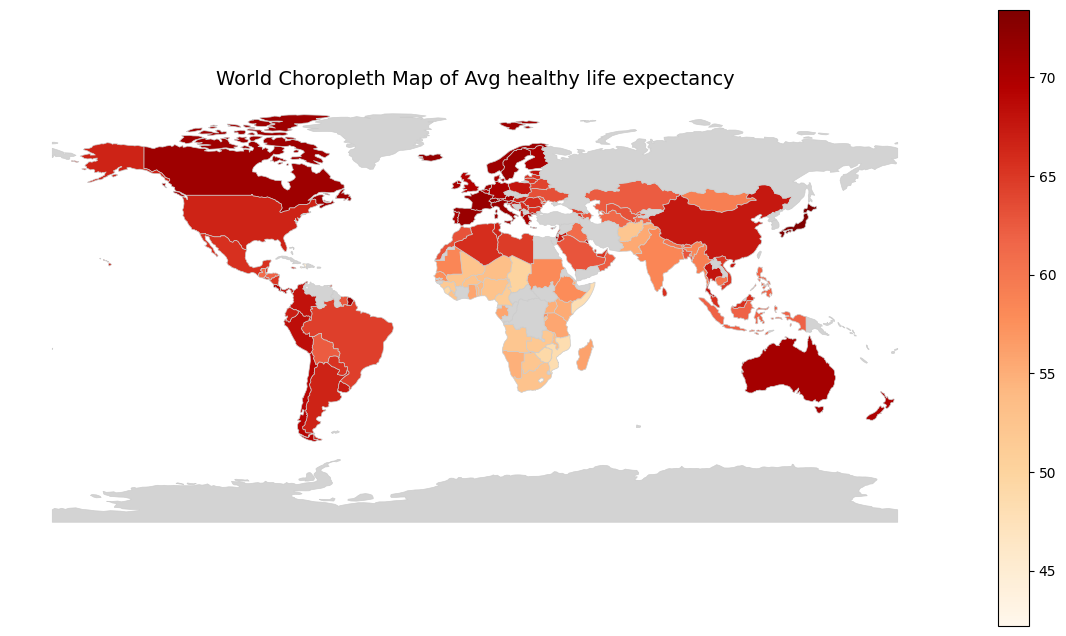

In [57]:
col_to_plot = "Avg healthy life expectancy"

fig, ax = plt.subplots(figsize=(15, 8))
merged.plot(
    column=col_to_plot,
    cmap="OrRd",
    linewidth=0.5,
    edgecolor="0.8",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "No data"}
)

ax.set_title(f"World Choropleth Map of {col_to_plot}", fontsize=14)
ax.axis("off")
plt.show()

**Interpretation.** Since we are dealing with air pollution globally, we have plotted a choropleth map to view the avg PM2.5 levels for each country based on its position on Earth.

From this map, we can see that there is strong regional differences in average PM2.5 levels. South Asia has the highest levels, followed by some parts in the Middle East, Central Asia and Africa. Southeast Asia generally falls within the moderate range, while the Americas, Australia, and majority of Europe has comparatively lower PM2.5 levels.


**Limitations** As we have removed a few countries in the Data Preparation Stage, we lack the data from some countries. However, we can still interpret a general trend among the different continents.

## Possible actions based on results (Act)

**Long-term:**

Governments and policymakers of countries with unhealthy PM2.5 levels should prioritise enforcing stricter regulations involving air pollution such as setting industrial emission caps, planning transitions to cleaner energy sources and improving their transportation infrastructure to reduce vehicle emissions. 

**Short-term:**

In countries with serious air pollution issues, governments could implement real-time air quality warning systems to warn their population to wear masks or stay indoors. Policymakers should also consider setting price caps and making face masks more commercially available.

## Final Reflection

### **Data Ethics:** 

Our datasets fail to account for developing nations or specific regions that might lack proper infrastructure to monitor PM2.5 levels. As a result, countries and regions that are the most vulnerable to severe air pollution might be underrepresented or missing from our datasets. 
Since our analysis relies on global health and economic metrics, we would need to verify our data to ensure proper attribution is given to relevant organisations such as the World Health Organisation and that any future publication of this notebook complies with their licenses

### **Data Security/Privacy:**


Since our datasets only contain aggregated data at the national level, the dataset is purely open data and does not contain any personally identifiable information or individual records. Therefore, there are no special risks regarding the exposure of sensitive data and no special measures need to be taken to ensure data privacy or security when considering a data science deployment.

### **Technical Challenges Faced:**

1. During our Ask and Prepare phase, our group was interested in investigating about air pollution. Initially, we wanted to investigate how air pollution affects happiness. However, we were unable to find suitable datasets that had good coverage of both air pollution and happiness. Furthermore, our TA suggested that it is a good practice to have a dataset which already includes both of the main variables to test, as it would be more reliable. Thus, we conducted further research and decided to change our topic to how air pollution affects life expectancy.

<br>

2. During our data processing stage, we were looking for ways to structure our data and aggregate the relevant information from different datasets. However, the datasets had different data representations such as inconsistent naming conventions, especially for country names. Data was also collected in different time intervals for different datasets, so we had to aggregate some data to produce a yearly mean in order to have matching time intervals. While thinking of ways to deal with null values, we struggled with finding out why our code for data imputation did not work, and had to implement code to display affected rows to visualise the issue.

<br>

3. During the analysis phase, we encountered a significant pivot when our plots revealed that our data is not normally distributed. They are either heavily right skewed or left skewed. After a team deliberation on whether to transform the data or move to a non-parametric approach, we opted to transition from an independent t-test to the Mann-Whitney U test.  While this transition initially challenged our interpretation of the results, it ultimately provided a more robust and honest reflection of our dataset, ensuring that our findings remained statistically valid despite the non-normal distribution. 